In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
filename = "C:/Users/pumam/OneDrive - UC San Diego/Desktop/SLEAP/labels.v001-cs-01.000_cs-1-trial 0.analysis.h5"


In [3]:
with h5py.File(filename, "r") as f:
    dset_names = list(f.keys())
    locations = f["tracks"][:].T
    node_names = [n.decode() for n in f["node_names"][:]]

print("===filename===")
print(filename)
print()

print("===HDF5 datasets===")
print(dset_names)
print()

print("===locations data shape===")
print(locations.shape)
print()

print("===nodes===")
for i, name in enumerate(node_names):
    print(f"{i}: {name}")
print()

===filename===
C:/Users/pumam/OneDrive - UC San Diego/Desktop/SLEAP/labels.v001-cs-01.000_cs-1-trial 0.analysis.h5

===HDF5 datasets===
['edge_inds', 'edge_names', 'instance_scores', 'labels_path', 'node_names', 'point_scores', 'provenance', 'track_names', 'track_occupancy', 'tracking_scores', 'tracks', 'video_ind', 'video_path']

===locations data shape===
(196, 9, 2, 1)

===nodes===
0: head
1: thorax
2: belly
3: LF
4: RF
5: LM
6: RM
7: LR
8: RR



In [4]:
frame_count, node_count, _, instance_count = locations.shape

print("frame count:", frame_count)
print("node count:", node_count)
print("instance count:", instance_count)

frame count: 196
node count: 9
instance count: 1


In [5]:
from scipy.interpolate import interp1d

def fill_missing(Y, kind="linear"):
    """Fills missing values independently along each dimension after the first."""

    # Store initial shape.
    initial_shape = Y.shape

    # Flatten after first dim.
    Y = Y.reshape((initial_shape[0], -1))

    # Interpolate along each slice.
    for i in range(Y.shape[-1]):
        y = Y[:, i]

        # Build interpolant.
        x = np.flatnonzero(~np.isnan(y))
        f = interp1d(x, y[x], kind=kind, fill_value=np.nan, bounds_error=False)

        # Fill missing
        xq = np.flatnonzero(np.isnan(y))
        y[xq] = f(xq)
        
        # Fill leading or trailing NaNs with the nearest non-NaN values
        mask = np.isnan(y)
        y[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), y[~mask])

        # Save slice
        Y[:, i] = y

    # Restore to initial shape.
    Y = Y.reshape(initial_shape)

    return Y

In [6]:
locations = fill_missing(locations)

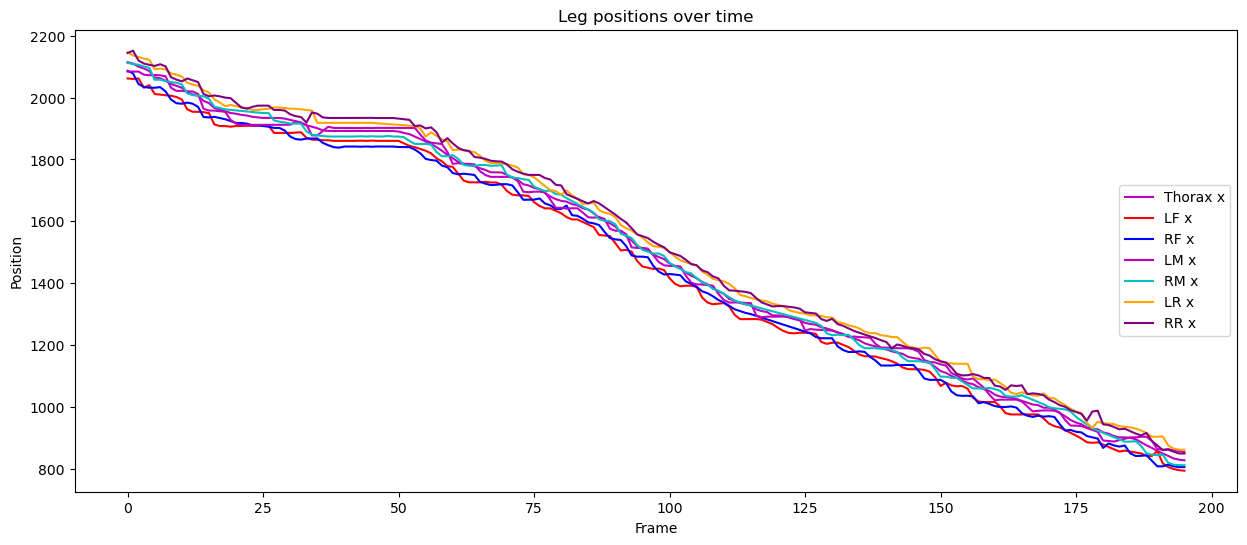

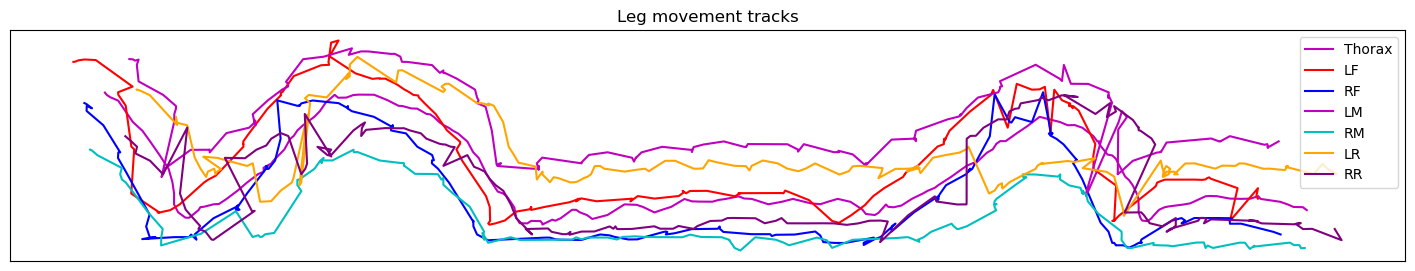

In [7]:
# Define indices for legs
Thorax_INDEX = 1
LF_INDEX = 3
RF_INDEX = 4
LM_INDEX = 5
RM_INDEX = 6
LR_INDEX = 7
RR_INDEX = 8

# Extract locations for each leg (single fly)
Thorax_loc = locations[:, Thorax_INDEX, :, 0] # thorax
lf_loc = locations[:, LF_INDEX, :, 0]  # Left Front
rf_loc = locations[:, RF_INDEX, :, 0]  # Right Front
lm_loc = locations[:, LM_INDEX, :, 0]  # Left Middle
rm_loc = locations[:, RM_INDEX, :, 0]  # Right Middle
lr_loc = locations[:, LR_INDEX, :, 0]  # Left Rear
rr_loc = locations[:, RR_INDEX, :, 0]  # Right Rear

# Define colors and labels for each leg
colors = ['m','r', 'b', 'm', 'c', 'orange', 'purple']
labels = ['Thorax','LF', 'RF', 'LM', 'RM', 'LR', 'RR']
leg_locs = [Thorax_loc, lf_loc, rf_loc, lm_loc, rm_loc, lr_loc, rr_loc]

# Plot movement over time
plt.figure(figsize=(15, 6))
for i, (leg, color, label) in enumerate(zip(leg_locs, colors, labels)):
    plt.plot(leg[:, 0], color, label=f'{label} x')  # X-axis
    #plt.plot(-1 * leg[:, 1], color, linestyle='dashed')  # Y-axis (negated for consistency)

plt.legend(loc="center right")
plt.title("Leg positions over time")
plt.xlabel("Frame")
plt.ylabel("Position")
#plt.savefig("legs poistions over time.pdf")

# Plot movement trajectories in 2D space
plt.figure(figsize=(18, 3))
for leg, color, label in zip(leg_locs, colors, labels):
    plt.plot(leg[:, 0], leg[:, 1], color, label=label)

plt.legend()
#plt.xlim(0, 1024)
plt.xticks([])
#plt.ylim(0, 1024)
plt.yticks([])
plt.title("Leg movement tracks")
#plt.savefig("two-legs track.pdf")
plt.show()


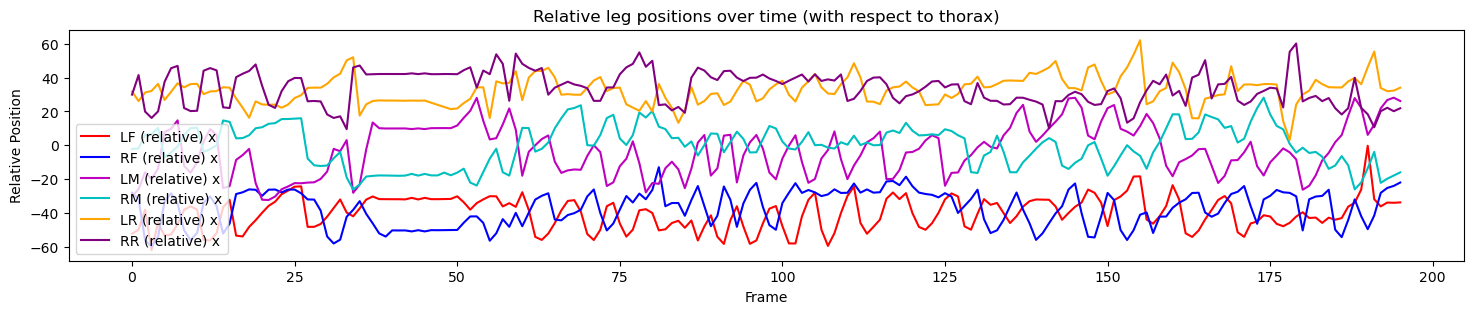

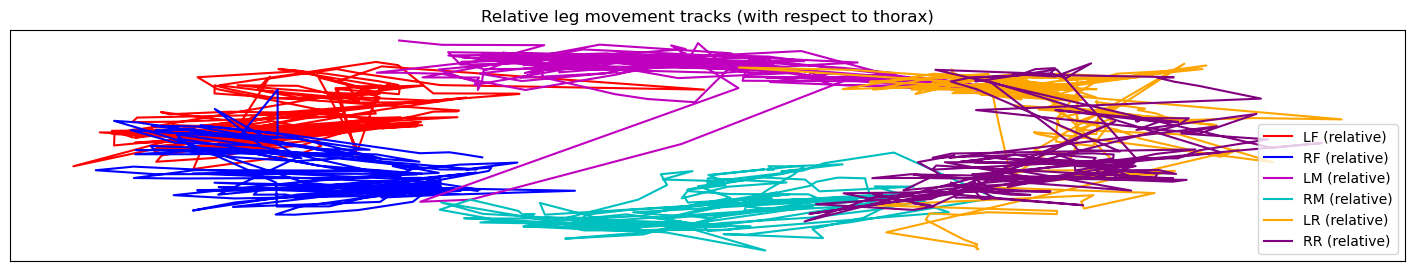

In [8]:
# Calculate relative positions of the legs with respect to the thorax
lf_relative = lf_loc - Thorax_loc
rf_relative = rf_loc - Thorax_loc
lm_relative = lm_loc - Thorax_loc
rm_relative = rm_loc - Thorax_loc
lr_relative = lr_loc - Thorax_loc
rr_relative = rr_loc - Thorax_loc
# Define colors and labels for each leg
colors = ['r', 'b', 'm', 'c', 'orange', 'purple']
labels = ['LF (relative)', 'RF (relative)', 'LM (relative)', 'RM (relative)', 'LR (relative)', 'RR (relative)']
relative_leg_locs = [lf_relative, rf_relative, lm_relative, rm_relative, lr_relative, rr_relative]

# Plot relative movement over time
plt.figure(figsize=(18, 3))
for i, (leg, color, label) in enumerate(zip(relative_leg_locs, colors, labels)):
    plt.plot(leg[:, 0], color, label=f'{label} x')  # X-axis
    #plt.plot(-1 * leg[:, 1], color, linestyle='dashed')  # Y-axis (negated for consistency)

plt.legend(loc="lower left")
plt.title("Relative leg positions over time (with respect to thorax)")
plt.xlabel("Frame")
plt.ylabel("Relative Position")
#plt.savefig("relative_legs_positions_over_time.pdf")

## Plot relative movement trajectories in 2D space
plt.figure(figsize=(18, 3))
for leg, color, label in zip(relative_leg_locs, colors, labels):
    plt.plot(leg[:, 0], leg[:,1], color, label=label)

plt.legend()
#plt.xlim(0, 1024)
plt.xticks([])
#plt.ylim(0, 1024)
plt.yticks([])
plt.title("Relative leg movement tracks (with respect to thorax)")
#plt.savefig("relative_two_legs_track.pdf")
plt.show()

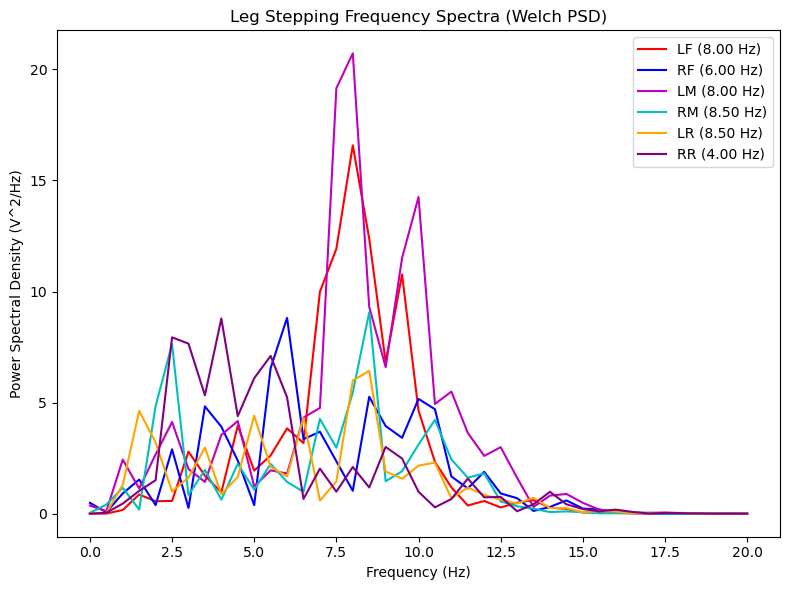

Dominant stepping frequencies:
LF: 8.00 Hz
RF: 6.00 Hz
LM: 8.00 Hz
RM: 8.50 Hz
LR: 8.50 Hz
RR: 4.00 Hz


In [43]:
from scipy.signal import welch, butter, filtfilt
# 1. Define a Butterworth Bandpass Filter (1.5 Hz to 15 Hz)
lowcut, highcut = 1.5, 15.0
b, a = butter(2, [lowcut, highcut], btype='bandpass', fs=fs)

plt.figure(figsize=(8, 6))
dominant_freqs = []

for leg, label, color in zip(legs, labels, colors):
    signal = leg[:, 0]
    
    # Check for NaN values from SLEAP tracking and interpolate if necessary
    if np.isnan(signal).any():
        nans = np.isnan(signal)
        signal[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), signal[~nans])

    # 2. Apply bandpass filter to remove low-frequency drift and high-frequency jitter
    filtered_signal = filtfilt(b, a, signal)

    # 3. Compute Power Spectral Density using Welch's Method
    # nperseg controls frequency resolution; fs * 2 gives 0.5 Hz resolution
    freqs, psd = welch(filtered_signal, fs=fs, nperseg=min(len(filtered_signal), fs * 2))

    # 4. Restrict peak search strictly to the gait region (1.5–12 Hz)
    gait_mask = (freqs >= 0) & (freqs <= 12.0)
    
    if np.any(gait_mask):
        freqs_gait = freqs[gait_mask]
        psd_gait = psd[gait_mask]
        
        peak_idx = np.argmax(psd_gait)
        dominant_freq = freqs_gait[peak_idx]
    else:
        dominant_freq = 0.0

    dominant_freqs.append(dominant_freq)

    # 5. Plot PSD (up to 20 Hz for clarity)
    plot_mask = (freqs >= 0) & (freqs <= 20.0)
    plt.plot(freqs[plot_mask], psd[plot_mask], color=color, label=f"{label} ({dominant_freq:.2f} Hz)")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V^2/Hz)")
plt.title("Leg Stepping Frequency Spectra (Welch PSD)")
plt.legend()
plt.tight_layout()
plt.show()

print("Dominant stepping frequencies:")
for label, f in zip(labels, dominant_freqs):
    print(f"{label}: {f:.2f} Hz")